In [2]:
import pandas as pd
from pathlib import Path

MOVIE_DATA_DIR = "D:\\DP\\data\\movie_remakes\\MovieRemakeDataset_NAACL2018"
STORIES_FILE_NAME = "movieRemakesManuallyCleaned.tsv"

def load_movie_remakes_data(dir):
    filename = "movieRemakesManuallyCleaned.tsv"
    # form readme
    # 1. The dataset is contained in movieRemakesManuallyCleaned.tsv It contains one line for each remake cluster. Each line starts with a cluster id followed by a list of movies that are remakes of each other. A movie is represented using its id, title and summary text.
    with open(Path(dir) / filename, "r", encoding="utf-8") as f:
        lines = f.readlines()

    # each line is a cluster of stories
    # each line starts with a cluster id followed by a list of movies that are remakes of each other. A movie is represented using its id, title and summary text.
    data_points = []
    for line in lines:
        cluster_id, movies = line.split("\t", 1)
        movies = movies.split("\t")
        for start_idx in range(0, len(movies), 3):
            data_points.append({"cluster_id": cluster_id, "title_id": movies[start_idx].strip(), "title": movies[start_idx + 1].strip(), "summary": movies[start_idx + 2].strip()})
    df = pd.DataFrame(data_points)
    return df   

movie_remakes_df = load_movie_remakes_data(MOVIE_DATA_DIR)
movie_remakes_df.head()


,cluster_id,title_id,title,summary
0,1,14141235,12_(2007_film),The jury decides whether a young Chechen boy i...
1,1,11081144,12_Angry_Men_(1997_film),After the final closing arguments have been pr...
2,1,11094452,Ek_Ruka_Hua_Faisla,The story begins in a courtroom where a teenag...
3,1,92605,12_Angry_Men_(1957_film),The story begins in a courtroom where an 18-ye...
4,2,21798180,13_(2010_film),"Vincent ""Vince"" Ferro overhears people talkin..."


In [3]:
cluster_summaries_df = movie_remakes_df.groupby("cluster_id")
assert len(cluster_summaries_df) == 266, f"There should be 266 clusters according to ReadMe.txt, got {len(cluster_summaries_df)}"
cluster_summaries_df.head()


,cluster_id,title_id,title,summary
0,1,14141235,12_(2007_film),The jury decides whether a young Chechen boy i...
1,1,11081144,12_Angry_Men_(1997_film),After the final closing arguments have been pr...
2,1,11094452,Ek_Ruka_Hua_Faisla,The story begins in a courtroom where a teenag...
3,1,92605,12_Angry_Men_(1957_film),The story begins in a courtroom where an 18-ye...
4,2,21798180,13_(2010_film),"Vincent ""Vince"" Ferro overhears people talkin..."
...,...,...,...,...
572,301,3990824,The_Major_and_the_Minor,After her client Albert Osborne makes a pass ...
573,302,158982,You%27ve_Got_Mail,Kathleen Kelly is involved with Frank Navasky...
574,302,193862,Pillow_Talk_(film),"Jan Morrow is a successful, content, self-rel..."
575,302,3535920,In_the_Good_Old_Summertime,Veronica Fisher enters Oberkugen's music shop...


In [4]:
def save_dataset_as_xml(df, output_file):
    df = df.sample(frac=1).reset_index(drop=True)
    output_file = output_file / "randomized.txt"
    with open(output_file, 'w', encoding='utf-8') as f:
        for _, row in df.iterrows():
            title_id = row['title_id']
            summary = row['summary']
            f.write(f"<title id={row['title']}>{summary}</title>")

    print(f"Dataset saved in XML-like format to {output_file}")

output_path = Path(MOVIE_DATA_DIR) / "clusters"
output_path.mkdir(parents=True, exist_ok=True)
save_dataset_as_xml(movie_remakes_df, output_path)





Dataset saved in XML-like format to D:\DP\data\movie_remakes\MovieRemakeDataset_NAACL2018\clusters\randomized.txt


In [5]:
movie_remakes_df[movie_remakes_df["title"].isin(["Howl%27s_Moving_Castle_(film)", "Ring_(film)"])]


,cluster_id,title_id,title,summary
441,233,180785,Ring_(film),"Two teenagers, Masami and Tomoko talk about ..."


In [6]:
movie_remakes_df[movie_remakes_df["cluster_id"].isin(['233'])]


,cluster_id,title_id,title,summary
440,233,62668,The_Ring_(2002_film),16-year-old Katie Embry and 17-year-old Becca...
441,233,180785,Ring_(film),"Two teenagers, Masami and Tomoko talk about ..."


# Token length of Movie Remakes Dataset

Fetching 30 files:   0%|          | 0/30 [00:00<?, ?it/s]

577
577


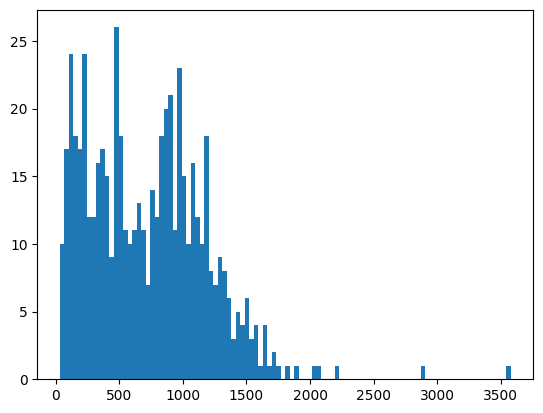

count     577.000000
mean      722.161179
std       461.409100
min        33.000000
25%       338.000000
50%       691.000000
75%      1031.000000
max      3578.000000
Name: summary_token_length, dtype: float64

In [17]:
from FlagEmbedding import BGEM3FlagModel
from matplotlib import pyplot as plt

model = BGEM3FlagModel(
    model_name_or_path="BAAI/bge-m3",
    device="cuda",
    query_max_length=1024,
    passage_max_length=8096,
    num_workers=4,
    batch_size=128,
)


summaries = movie_remakes_df["summary"].tolist()
tokenized_summaries = model.tokenizer(summaries, padding=False, truncation=True)
print(len(summaries))
print(len(tokenized_summaries["input_ids"]))
movie_remakes_df["summary_token_length"] = [len(input_ids) for input_ids in tokenized_summaries["input_ids"]]


plt.hist(movie_remakes_df["summary_token_length"], bins=100)
plt.show()

movie_remakes_df["summary_token_length"].describe()

